# 01 — Exploratory Data Analysis (EDA)
**Evaluasi Robustness Model Sentimen Bahasa Indonesia terhadap Noise Sintetis**

Tujuan notebook ini:
1. Memahami distribusi label
2. Menganalisis karakteristik teks (panjang tweet, token)
3. Mengidentifikasi noise alami dalam dataset
4. Menyimpulkan insight untuk tahap preprocessing

> ⚙️ Runtime: **CPU** (tidak butuh GPU)

## Cell 1 — Mount Drive & Import Config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/sentiment-robustness-id/src')
from config import *

print(f'ROOT: {ROOT}')
print('✅ Config loaded')

Mounted at /content/drive
ROOT: /content/drive/MyDrive/sentiment-robustness-id
✅ Config loaded


## Cell 2 — Install & Import Library

In [2]:
!pip install wordcloud matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Style plot
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ Library siap')

✅ Library siap


## Cell 3 — Load Dataset

In [3]:
df = pd.read_csv(RAW_DATA_PATH, sep='\t')

print('=== DATASET INFO ===')
print(f'Shape      : {df.shape}')
print(f'Columns    : {df.columns.tolist()}')
print(f'Null values:\n{df.isnull().sum()}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'\nSample data:')
df.head(5)

=== DATASET INFO ===
Shape      : (23644, 4)
Columns    : ['Date', 'User', 'Tweet', 'sentiment']
Null values:
Date         0
User         0
Tweet        0
sentiment    0
dtype: int64

Duplicate rows: 0

Sample data:


,Date,User,Tweet,sentiment
0,2022-03-31 14:32:04+00:00,pikobar_jabar,Ketahui informasi pembagian #PPKM di wilayah J...,1
1,2022-03-31 09:26:00+00:00,inewsdotid,Tempat Ibadah di Wilayah PPKM Level 1 Boleh Be...,1
2,2022-03-31 05:02:34+00:00,vdvc_talk,"Juru bicara Satgas Covid-19, Wiku Adisasmito m...",1
3,2022-03-30 14:23:10+00:00,pikobar_jabar,Ketahui informasi pembagian #PPKM di wilayah J...,1
4,2022-03-30 11:28:57+00:00,tvOneNews,Kementerian Agama menerbitkan Surat Edaran Nom...,1


## Cell 4 — Distribusi Label

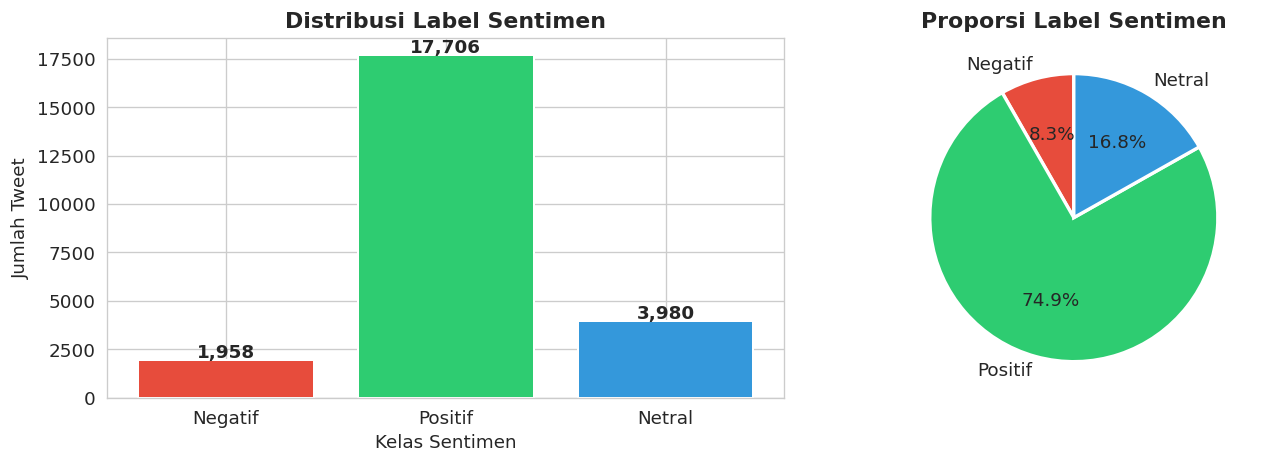


=== LABEL DISTRIBUTION ===
  Negatif   :  1,958 (8.3%)
  Positif   : 17,706 (74.9%)
  Netral    :  3,980 (16.8%)
  TOTAL     : 23,644


In [4]:
label_counts = df[LABEL_COLUMN].value_counts().sort_index()
label_names  = [LABEL_MAP[i] for i in label_counts.index]
colors       = ['#e74c3c', '#2ecc71', '#3498db']  # Negatif, Positif, Netral

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(label_names, label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribusi Label Sentimen', fontweight='bold')
axes[0].set_xlabel('Kelas Sentimen')
axes[0].set_ylabel('Jumlah Tweet')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_names, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Label Sentimen', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_label_distribution.png', bbox_inches='tight')
plt.show()

print('\n=== LABEL DISTRIBUTION ===')
for idx, (name, count) in enumerate(zip(label_names, label_counts.values)):
    print(f'  {name:10s}: {count:6,} ({count/len(df)*100:.1f}%)')
print(f'  {"TOTAL":10s}: {len(df):6,}')

## Cell 5 — Analisis Panjang Tweet (Character Level)

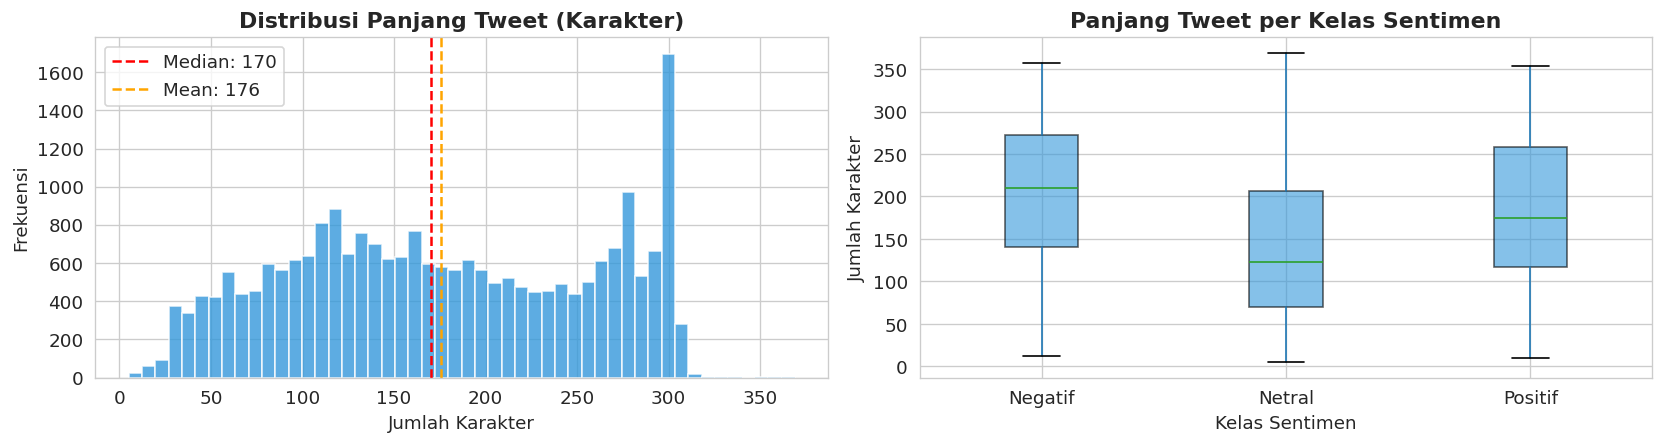

=== STATISTIK PANJANG TWEET (KARAKTER) ===
              count   mean   std   min    25%    50%    75%    max
label_name                                                        
Negatif      1958.0  199.5  78.0  12.0  141.0  210.0  272.0  357.0
Netral       3980.0  140.8  82.6   5.0   70.0  123.0  207.0  369.0
Positif     17706.0  181.2  80.2  10.0  117.0  175.0  258.0  354.0


In [5]:
df['char_len'] = df[TEXT_COLUMN].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram keseluruhan
axes[0].hist(df['char_len'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df['char_len'].median(), color='red', linestyle='--', label=f'Median: {df["char_len"].median():.0f}')
axes[0].axvline(df['char_len'].mean(), color='orange', linestyle='--', label=f'Mean: {df["char_len"].mean():.0f}')
axes[0].set_title('Distribusi Panjang Tweet (Karakter)', fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot per label
df['label_name'] = df[LABEL_COLUMN].map(LABEL_MAP)
df.boxplot(column='char_len', by='label_name', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1].set_title('Panjang Tweet per Kelas Sentimen', fontweight='bold')
axes[1].set_xlabel('Kelas Sentimen')
axes[1].set_ylabel('Jumlah Karakter')
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_char_length.png', bbox_inches='tight')
plt.show()

print('=== STATISTIK PANJANG TWEET (KARAKTER) ===')
print(df.groupby('label_name')['char_len'].describe().round(1))

## Cell 6 — Analisis Panjang Tweet (Word Level)

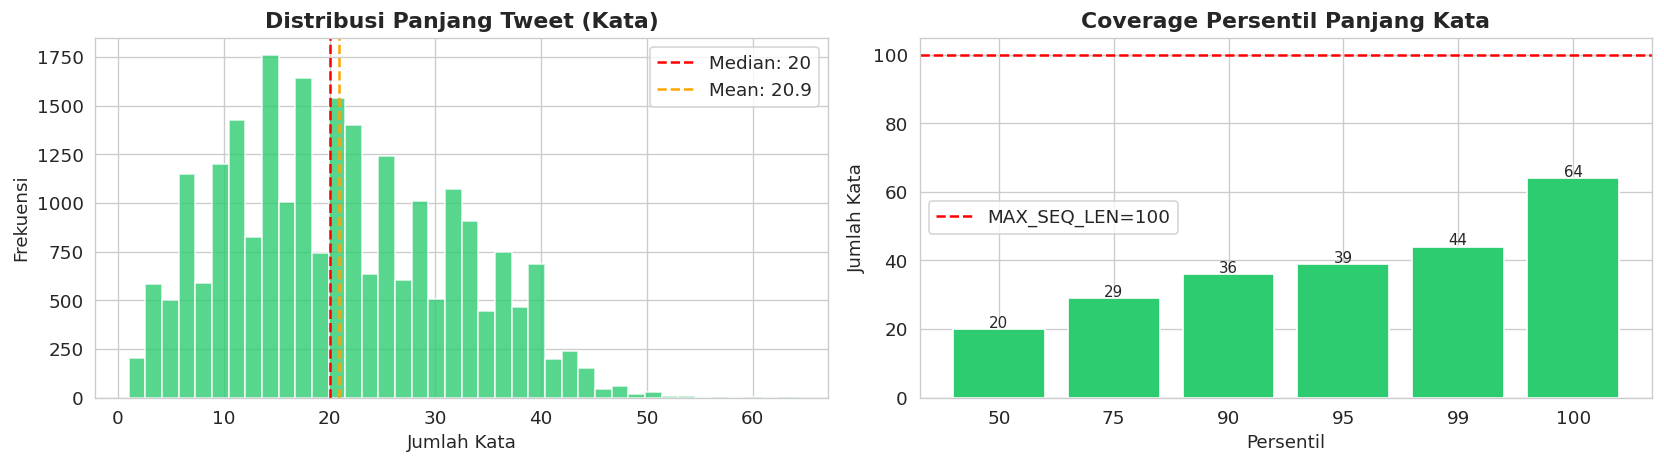

Coverage dengan MAX_SEQ_LEN=100: 100.0% data tercakup

=== STATISTIK PANJANG TWEET (KATA) ===
count    23644.0
mean        20.9
std         10.5
min          1.0
25%         13.0
50%         20.0
75%         29.0
max         64.0
Name: word_len, dtype: float64


In [6]:
df['word_len'] = df[TEXT_COLUMN].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['word_len'], bins=40, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[0].axvline(df['word_len'].median(), color='red', linestyle='--', label=f'Median: {df["word_len"].median():.0f}')
axes[0].axvline(df['word_len'].mean(), color='orange', linestyle='--', label=f'Mean: {df["word_len"].mean():.1f}')
axes[0].set_title('Distribusi Panjang Tweet (Kata)', fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Persentil coverage
percentiles = [50, 75, 90, 95, 99, 100]
pct_values  = [int(np.percentile(df['word_len'], p)) for p in percentiles]
axes[1].bar([str(p) for p in percentiles], pct_values, color='#2ecc71', edgecolor='white')
axes[1].axhline(MAX_SEQ_LEN, color='red', linestyle='--', label=f'MAX_SEQ_LEN={MAX_SEQ_LEN}')
axes[1].set_title('Coverage Persentil Panjang Kata', fontweight='bold')
axes[1].set_xlabel('Persentil')
axes[1].set_ylabel('Jumlah Kata')
axes[1].legend()
for i, v in enumerate(pct_values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_word_length.png', bbox_inches='tight')
plt.show()

coverage = (df['word_len'] <= MAX_SEQ_LEN).sum() / len(df) * 100
print(f'Coverage dengan MAX_SEQ_LEN={MAX_SEQ_LEN}: {coverage:.1f}% data tercakup')
print('\n=== STATISTIK PANJANG TWEET (KATA) ===')
print(df['word_len'].describe().round(1))

## Cell 7 — Deteksi Noise Alami dalam Dataset

=== DETEKSI NOISE ALAMI DALAM DATASET ===
  URL                      : 18,077 tweet (76.5%)
  Mention (@)              :  3,693 tweet (15.6%)
  Hashtag (#)              : 23,642 tweet (100.0%)
  Angka                    :  9,104 tweet (38.5%)
  Karakter Berulang        :  2,473 tweet (10.5%)
  Singkatan Umum           :  2,202 tweet (9.3%)
  Emoji/Simbol             :  3,983 tweet (16.8%)


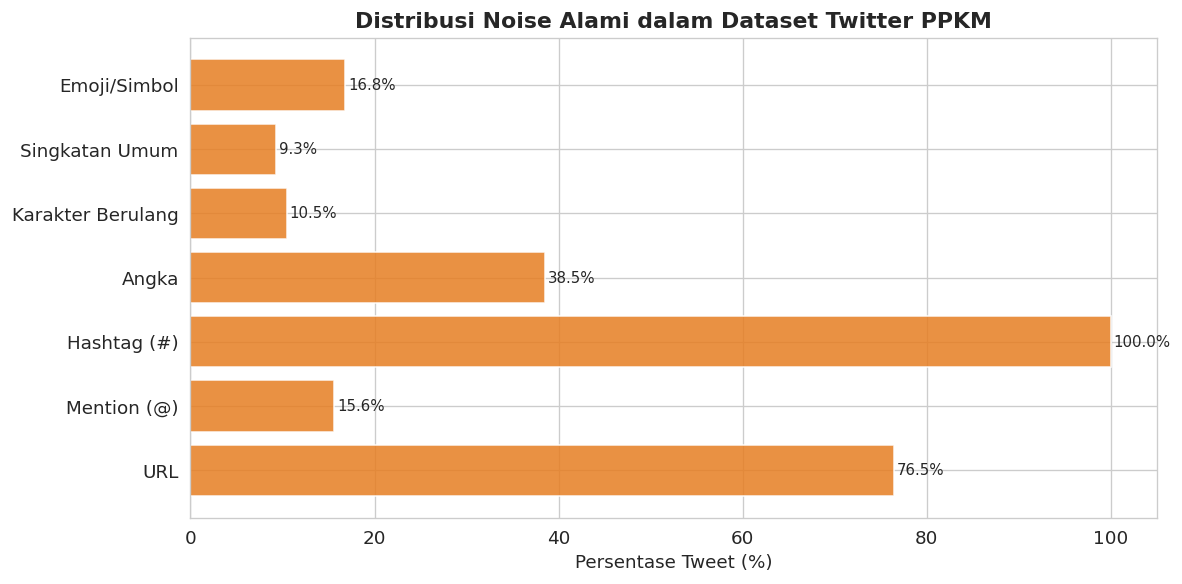

In [7]:
# Deteksi karakteristik noise alami Twitter Indonesia
tweets = df[TEXT_COLUMN].astype(str)

noise_patterns = {
    'URL'             : r'https?://\S+',
    'Mention (@)'     : r'@\w+',
    'Hashtag (#)'     : r'#\w+',
    'Angka'           : r'\b\d+\b',
    'Karakter Berulang': r'(.)\1{2,}',   # baguuus, parahhh
    'Singkatan Umum'  : r'\b(gak|gk|ga|tdk|yg|yg|dgn|utk|bgt|km|krn|tp|lg|jg|sdh|blm|msh)\b',
    'Emoji/Simbol'    : r'[^\x00-\x7F]+',
}

print('=== DETEKSI NOISE ALAMI DALAM DATASET ===')
results = {}
for name, pattern in noise_patterns.items():
    count = tweets.str.contains(pattern, regex=True).sum()
    pct   = count / len(df) * 100
    results[name] = {'count': count, 'pct': pct}
    print(f'  {name:25s}: {count:6,} tweet ({pct:.1f}%)')

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
pcts  = [results[n]['pct'] for n in names]
bars  = ax.barh(names, pcts, color='#e67e22', edgecolor='white', alpha=0.85)
ax.set_xlabel('Persentase Tweet (%)')
ax.set_title('Distribusi Noise Alami dalam Dataset Twitter PPKM', fontweight='bold')
for bar, val in zip(bars, pcts):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_noise_natural.png', bbox_inches='tight')
plt.show()

## Cell 8 — WordCloud per Kelas Sentimen

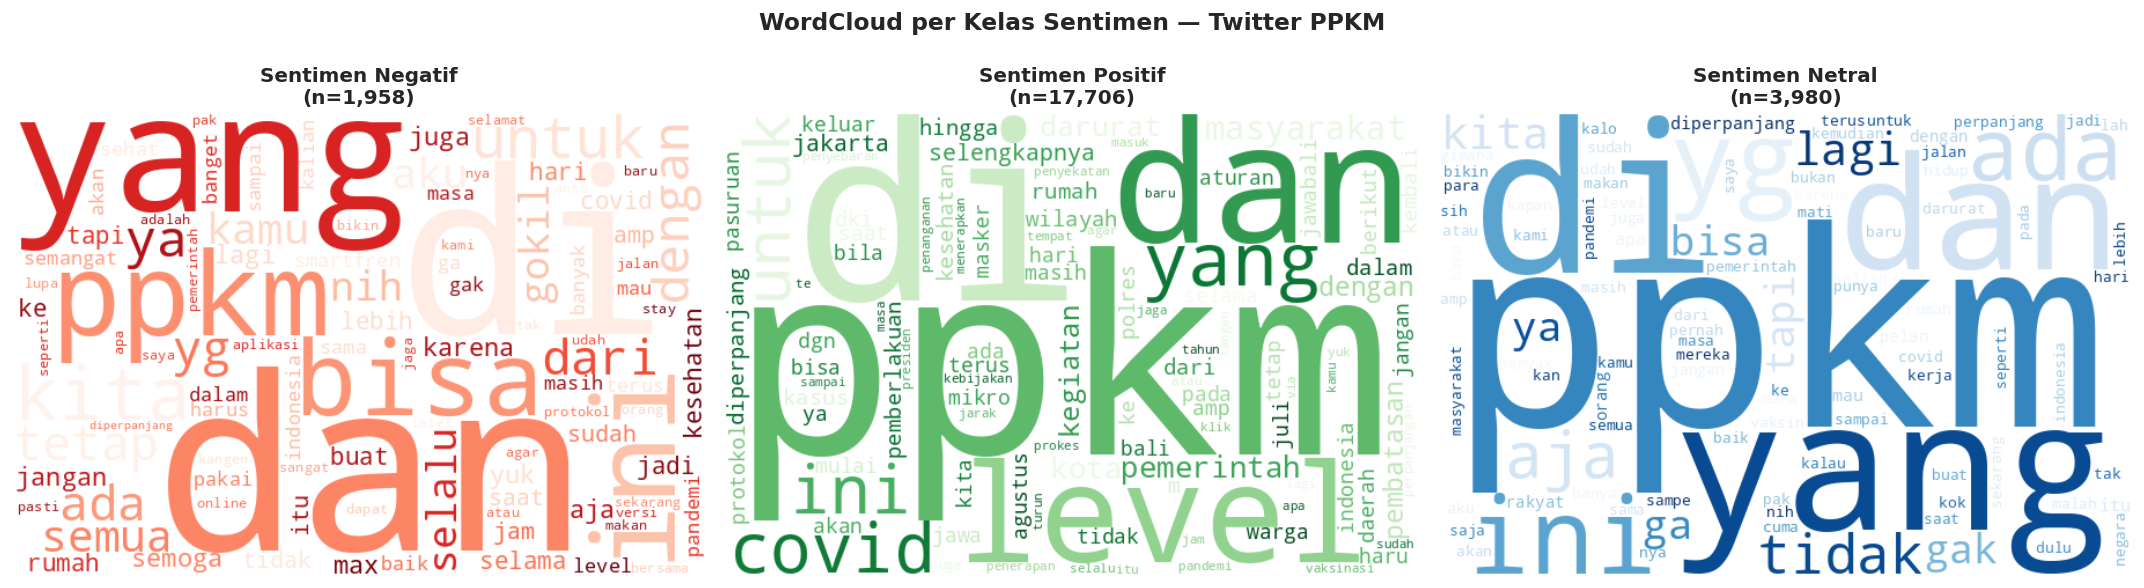

In [8]:
def clean_for_wordcloud(text):
    text = re.sub(r'https?://\S+', '', text)   # hapus URL
    text = re.sub(r'@\w+', '', text)            # hapus mention
    text = re.sub(r'#\w+', '', text)            # hapus hashtag
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # hapus non-huruf
    return text.lower().strip()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_wc = ['Reds', 'Greens', 'Blues']

for idx, (label_id, label_name) in enumerate(LABEL_MAP.items()):
    subset = df[df[LABEL_COLUMN] == label_id][TEXT_COLUMN].astype(str)
    text   = ' '.join(subset.apply(clean_for_wordcloud))

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colors_wc[idx],
        max_words=100,
        collocations=False
    ).generate(text)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Sentimen {label_name}\n(n={len(subset):,})', fontweight='bold', fontsize=12)

plt.suptitle('WordCloud per Kelas Sentimen — Twitter PPKM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_wordcloud.png', bbox_inches='tight')
plt.show()

## Cell 9 — Top 20 Kata per Kelas Sentimen

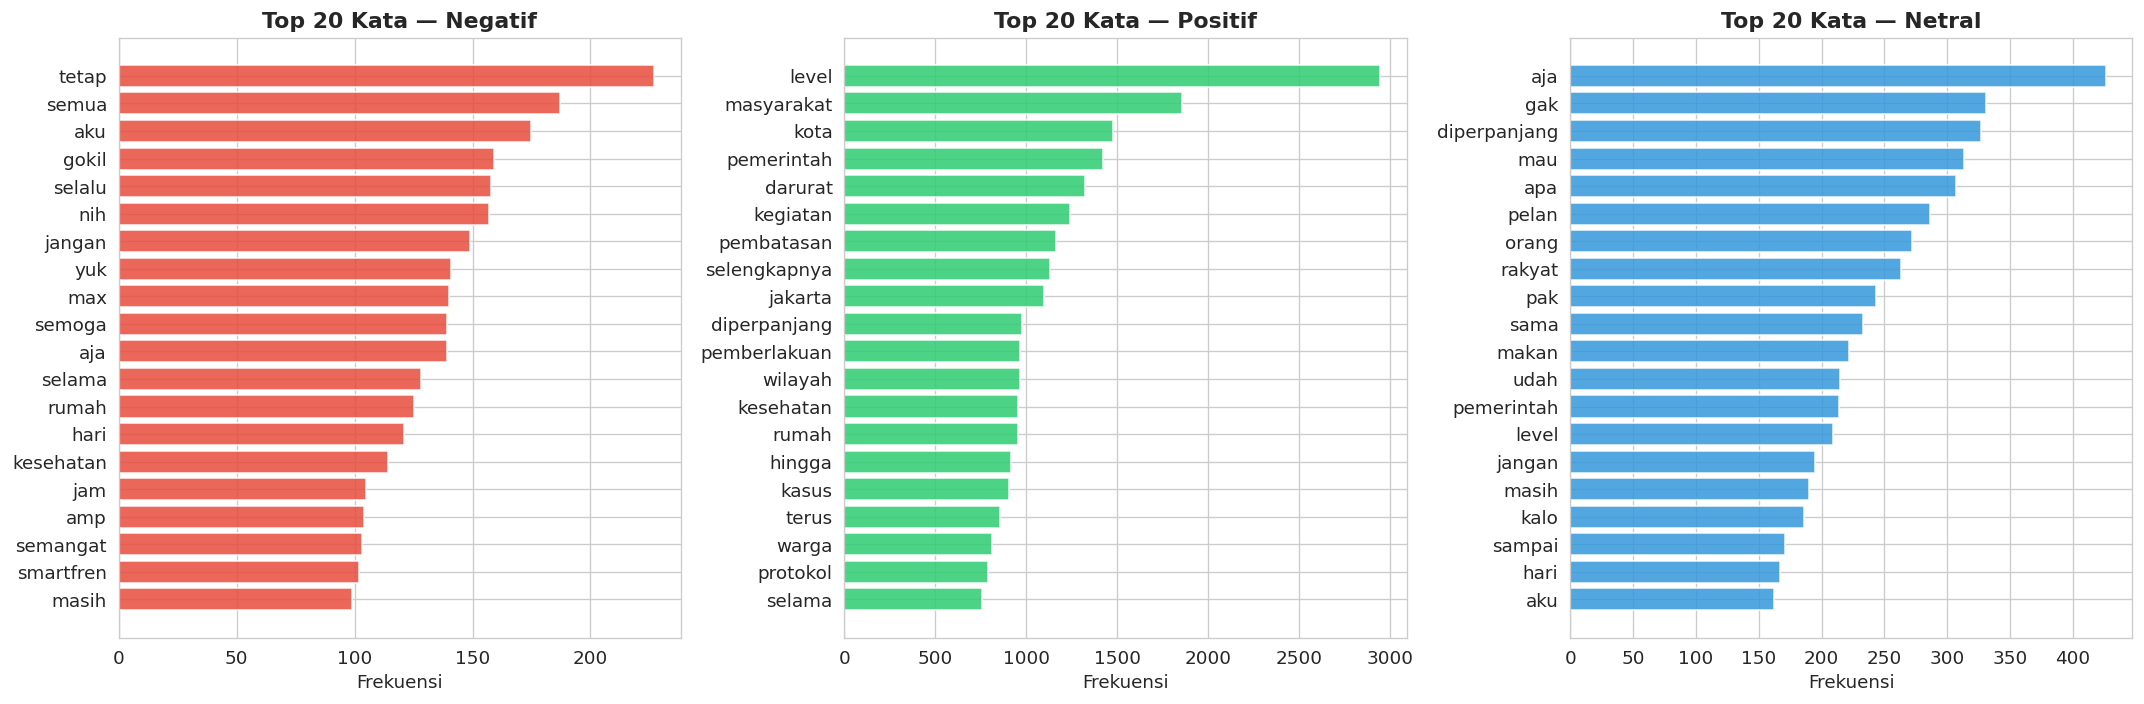

In [9]:
# Stopwords Indonesia sederhana
STOPWORDS_ID = set([
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'pada', 'adalah', 'akan', 'tidak', 'ada', 'juga', 'sudah', 'bisa',
    'dalam', 'atau', 'karena', 'saat', 'lebih', 'oleh', 'agar', 'kami',
    'kita', 'mereka', 'saya', 'kamu', 'ia', 'nya', 'para', 'se', 'pun',
    'ppkm', 'covid', 'tapi', 'jadi', 'kalau', 'bagi', 'buat', 'lagi'
])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_colors = ['#e74c3c', '#2ecc71', '#3498db']

for idx, (label_id, label_name) in enumerate(LABEL_MAP.items()):
    subset = df[df[LABEL_COLUMN] == label_id][TEXT_COLUMN].astype(str)
    words  = ' '.join(subset.apply(clean_for_wordcloud)).split()
    words  = [w for w in words if w not in STOPWORDS_ID and len(w) > 2]
    top20  = Counter(words).most_common(20)

    words_list = [w for w, _ in top20]
    counts     = [c for _, c in top20]

    axes[idx].barh(words_list[::-1], counts[::-1], color=bar_colors[idx], alpha=0.85, edgecolor='white')
    axes[idx].set_title(f'Top 20 Kata — {label_name}', fontweight='bold')
    axes[idx].set_xlabel('Frekuensi')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_top_words.png', bbox_inches='tight')
plt.show()

## Cell 10 — Class Imbalance Analysis & Rekomendasi

In [10]:
print('=== CLASS IMBALANCE ANALYSIS ===')
label_counts = df[LABEL_COLUMN].value_counts().sort_index()
majority     = label_counts.max()
minority     = label_counts.min()
ratio        = majority / minority

for label_id, count in label_counts.items():
    print(f'  {LABEL_MAP[label_id]:10s}: {count:6,} ({count/len(df)*100:.1f}%)')

print(f'\nImbalance ratio (majority/minority): {ratio:.1f}x')

print('\n=== REKOMENDASI HANDLING IMBALANCE ===')
if ratio > 5:
    print('  ⚠️  Imbalance TINGGI (ratio > 5x)')
    print('  → Gunakan class_weight="balanced" saat training')
    print('  → Gunakan stratified split untuk train/val/test')
    print('  → Evaluasi dengan Macro F1, bukan hanya Accuracy')
elif ratio > 2:
    print('  ⚠️  Imbalance SEDANG (ratio 2-5x)')
    print('  → Gunakan stratified split')
    print('  → Evaluasi dengan Macro F1')
else:
    print('  ✅ Distribusi relatif seimbang')

# Hitung class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=df[LABEL_COLUMN].values
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f'\nClass weights yang akan digunakan saat training:')
for label_id, weight in class_weight_dict.items():
    print(f'  {LABEL_MAP[label_id]:10s} (label {label_id}): {weight:.4f}')

=== CLASS IMBALANCE ANALYSIS ===
  Negatif   :  1,958 (8.3%)
  Positif   : 17,706 (74.9%)
  Netral    :  3,980 (16.8%)

Imbalance ratio (majority/minority): 9.0x

=== REKOMENDASI HANDLING IMBALANCE ===
  ⚠️  Imbalance TINGGI (ratio > 5x)
  → Gunakan class_weight="balanced" saat training
  → Gunakan stratified split untuk train/val/test
  → Evaluasi dengan Macro F1, bukan hanya Accuracy

Class weights yang akan digunakan saat training:
  Negatif    (label 0): 4.0252
  Positif    (label 1): 0.4451
  Netral     (label 2): 1.9802


## Cell 11 — Ringkasan EDA & Insight untuk Preprocessing

In [11]:
print('=' * 55)
print('       RINGKASAN EDA — INSIGHT UNTUK PREPROCESSING')
print('=' * 55)

print(f'''
📊 DATASET
  Total tweets      : {len(df):,}
  Duplikat          : {df.duplicated().sum()}
  Null values       : 0

🏷️  LABEL
  Kelas             : 3 (Negatif, Positif, Netral)
  Imbalance ratio   : {ratio:.1f}x
  → Gunakan stratified split + class_weight

📏 PANJANG TEKS
  Median kata       : {df["word_len"].median():.0f} kata
  Mean kata         : {df["word_len"].mean():.1f} kata
  Max kata          : {df["word_len"].max()} kata
  Coverage @{MAX_SEQ_LEN} kata: {(df["word_len"] <= MAX_SEQ_LEN).sum()/len(df)*100:.1f}%
  → MAX_SEQ_LEN={MAX_SEQ_LEN} sudah valid

🔤 NOISE ALAMI
  URL ditemukan di  : {tweets.str.contains(r'https?://\\S+', regex=True).sum()/len(df)*100:.1f}% tweet
  Mention ditemukan : {tweets.str.contains(r'@\\w+', regex=True).sum()/len(df)*100:.1f}% tweet
  Hashtag ditemukan : {tweets.str.contains(r'#\\w+', regex=True).sum()/len(df)*100:.1f}% tweet
  → URL, mention, hashtag wajib dihapus saat preprocessing
  → Karakter berulang & slang → input noise injection

✅ LANGKAH PREPROCESSING SELANJUTNYA
  1. Hapus duplikat
  2. Hapus URL, mention, hashtag
  3. Lowercase
  4. Hapus karakter non-alfanumerik berlebihan
  5. Stratified split 70/15/15
  6. Simpan ke data/processed/data_clean.csv
''')

print('=' * 55)
print('✅ EDA selesai. Lanjut ke 02_Preprocessing.ipynb')
print('=' * 55)

       RINGKASAN EDA — INSIGHT UNTUK PREPROCESSING

📊 DATASET
  Total tweets      : 23,644
  Duplikat          : 0
  Null values       : 0

🏷️  LABEL
  Kelas             : 3 (Negatif, Positif, Netral)
  Imbalance ratio   : 9.0x
  → Gunakan stratified split + class_weight

📏 PANJANG TEKS
  Median kata       : 20 kata
  Mean kata         : 20.9 kata
  Max kata          : 64 kata
  Coverage @100 kata: 100.0%
  → MAX_SEQ_LEN=100 sudah valid

🔤 NOISE ALAMI
  URL ditemukan di  : 0.0% tweet
  Mention ditemukan : 0.0% tweet
  Hashtag ditemukan : 0.0% tweet
  → URL, mention, hashtag wajib dihapus saat preprocessing
  → Karakter berulang & slang → input noise injection

✅ LANGKAH PREPROCESSING SELANJUTNYA
  1. Hapus duplikat
  2. Hapus URL, mention, hashtag
  3. Lowercase
  4. Hapus karakter non-alfanumerik berlebihan
  5. Stratified split 70/15/15
  6. Simpan ke data/processed/data_clean.csv

✅ EDA selesai. Lanjut ke 02_Preprocessing.ipynb
